<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/mldl_exp_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

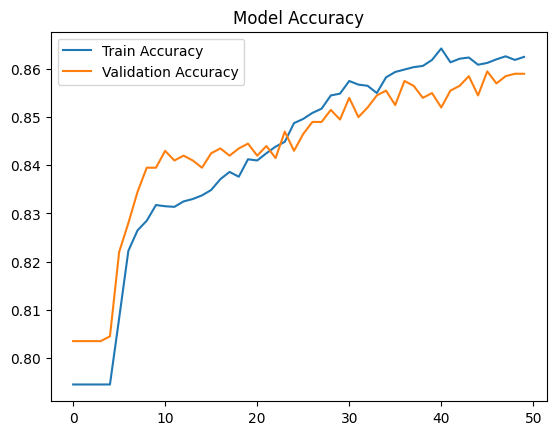

In [2]:
# ===============================
# ARTIFICIAL NEURAL NETWORK (ANN)
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ===============================
# STEP 1: LOAD DATA
# ===============================

data = pd.read_csv("Churn_Modelling.csv")
print(data.head())

# ===============================
# STEP 2: PREPROCESSING
# ===============================

# Drop unnecessary columns
data = data.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Encode categorical variables
label_encoder_gender = LabelEncoder()
data["Gender"] = label_encoder_gender.fit_transform(data["Gender"])

# One-hot encoding for Geography
data = pd.get_dummies(data, columns=["Geography"], drop_first=True)

# Split features and target
X = data.drop("Exited", axis=1)
y = data["Exited"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# STEP 3: BUILD ANN MODEL
# ===============================

model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(units=6, activation='relu'))

# Hidden Layer 2
model.add(Dense(units=6, activation='relu'))

# Output Layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ===============================
# STEP 4: TRAIN MODEL
# ===============================

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# ===============================
# STEP 5: EVALUATION
# ===============================

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ===============================
# STEP 6: VISUALIZATION
# ===============================

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Task
Calculate a full classification report, plot the training and validation loss over epochs, plot the Receiver Operating Characteristic (ROC) curve and calculate its Area Under the Curve (AUC), and plot the Precision-Recall curve for the Artificial Neural Network (ANN) model.

## Calculate and Display Full Classification Report

### Subtask:
Calculate and print a complete classification report including precision, recall, F1-score, and support for both classes using `sklearn.metrics.classification_report` based on the model's predictions (`y_pred`) and actual labels (`y_test`).


**Reasoning**:
To calculate and display the full classification report, I need to import the `classification_report` function, then use it with `y_test` and `y_pred` which are already available in the kernel.



In [3]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.73      0.45      0.56       393

    accuracy                           0.86      2000
   macro avg       0.80      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



## Plot Training and Validation Loss

### Subtask:
Generate a new plot to visualize the training loss and validation loss over epochs using the `history` object from model training. Include appropriate labels and a legend.


**Reasoning**:
To visualize the training and validation loss over epochs, I will use `matplotlib.pyplot` to plot the 'loss' and 'val_loss' from the `history` object, ensuring to add appropriate labels, a legend, and a title as instructed.



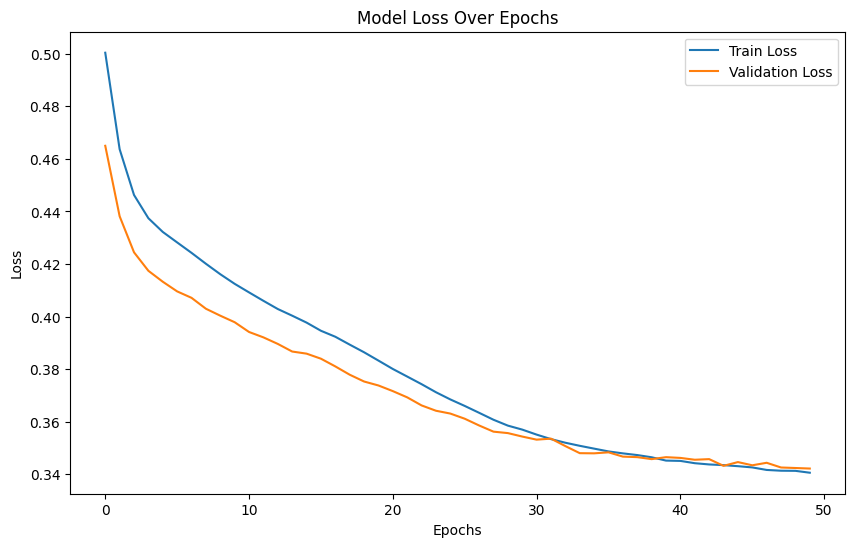

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Plot ROC Curve and Calculate AUC

### Subtask:
Generate a Receiver Operating Characteristic (ROC) curve to visualize the trade-off between true positive rate and false positive rate. Calculate and display the Area Under the Curve (AUC) score. This will require `sklearn.metrics.roc_curve` and `sklearn.metrics.auc`.


**Reasoning**:
To generate the ROC curve and calculate AUC, I need to import the `roc_curve` and `auc` functions from `sklearn.metrics`. Then, I will predict the probabilities using the trained model, compute the FPR, TPR, and thresholds, calculate the AUC, and finally plot the ROC curve with the calculated AUC score, along with a random classifier line and appropriate labels.



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


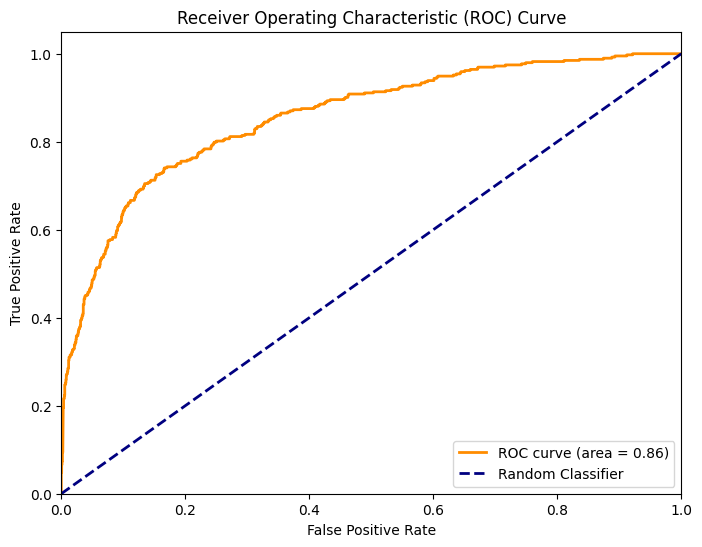

In [5]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_pred_proba = model.predict(X_test)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Plot ROC Curve and Calculate AUC

### Subtask:
Generate a Receiver Operating Characteristic (ROC) curve to visualize the trade-off between true positive rate and false positive rate. Calculate and display the Area Under the Curve (AUC) score. This will require `sklearn.metrics.roc_curve` and `sklearn.metrics.auc`.

## Plot Precision-Recall Curve

### Subtask:
Generate a Precision-Recall curve to visualize the trade-off between precision and recall for different probability thresholds. Calculate and display the Area Under the Curve (AUC) for the Precision-Recall curve. This will require `sklearn.metrics.precision_recall_curve` and `sklearn.metrics.auc`.

## Plot Precision-Recall Curve

### Subtask:
Generate a Precision-Recall curve to visualize the trade-off between precision and recall for different probability thresholds. Calculate and display the Area Under the Curve (AUC) for the Precision-Recall curve. This will require `sklearn.metrics.precision_recall_curve` and `sklearn.metrics.auc`.

## Plot Precision-Recall Curve

### Subtask:
Generate a Precision-Recall curve to visualize the trade-off between precision and recall for different probability thresholds. Calculate and display the Area Under the Curve (AUC) for the Precision-Recall curve. This will require `sklearn.metrics.precision_recall_curve` and `sklearn.metrics.auc`.

```markdown
## Plot Precision-Recall Curve

### Subtask:
Generate a Precision-Recall curve to visualize the trade-off between precision and recall for different probability thresholds. Calculate and display the Area Under the Curve (AUC) for the Precision-Recall curve. This will require `sklearn.metrics.precision_recall_curve` and `sklearn.metrics.auc`.
```

## Plot Precision-Recall Curve

### Subtask:
Generate a Precision-Recall curve to visualize the trade-off between precision and recall for different probability thresholds. Calculate and display the Area Under the Curve (AUC) for the Precision-Recall curve. This will require `sklearn.metrics.precision_recall_curve` and `sklearn.metrics.auc`.

## Plot Precision-Recall Curve

### Subtask:
Generate a Precision-Recall curve to visualize the trade-off between precision and recall for different probability thresholds. Calculate and display the Area Under the Curve (AUC) for the Precision-Recall curve. This will require `sklearn.metrics.precision_recall_curve` and `sklearn.metrics.auc`.

## Plot Precision-Recall Curve

### Subtask:
Generate a Precision-Recall curve to visualize the trade-off between precision and recall for different probability thresholds. Calculate and display the Area Under the Curve (AUC) for the Precision-Recall curve. This will require `sklearn.metrics.precision_recall_curve` and `sklearn.metrics.auc`.

**Reasoning**:
To generate the Precision-Recall curve and calculate its AUC, I need to import the `precision_recall_curve` and `auc` functions from `sklearn.metrics`. Then, I will use the previously calculated predicted probabilities (`y_pred_proba`), compute precision, recall, and thresholds, calculate the AUC, and finally plot the Precision-Recall curve with the calculated AUC score, along with appropriate labels.



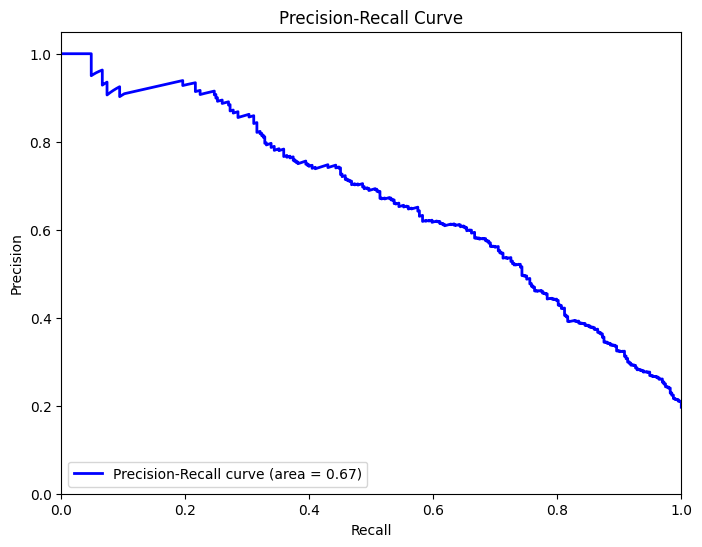

In [6]:
from sklearn.metrics import precision_recall_curve, auc

# Compute Precision-Recall curve and AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve (area = %0.2f)' % pr_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()